In [3]:
import pandas as pd


# Remplacez 'chemin_vers_fichier1.xlsx' et 'chemin_vers_fichier2.xlsx' par les chemins réels de vos fichiers
file_path1 = "players_stats_by_season_full_details.xlsx"
file_path2 = "NBA_Anthropometric.csv"

df1 = pd.read_excel(file_path1)
df2 = pd.read_csv(file_path2)

# Afficher les deux DataFrames
display(df1.head())
display(df2.head())

,League,Season,Stage,Player,Team,GP,MIN,FGM,FGA,3PM,...,birth_date,height,height_cm,weight,weight_kg,nationality,high_school,draft_round,draft_pick,draft_team
0,NBA,1999 - 2000,Regular_Season,Shaquille O'Neal,LAL,79,3163.0,956,1665,0,...,"Mar 6, 1972",2025-01-07 00:00:00,216.0,325.0,147.0,United States,Robert G. Cole High School,1.0,1.0,Orlando Magic
1,NBA,1999 - 2000,Regular_Season,Vince Carter,TOR,82,3126.0,788,1696,95,...,"Jan 26, 1977",2025-06-06 00:00:00,198.0,220.0,100.0,United States,Mainland High School,1.0,5.0,Golden State Warriors
2,NBA,1999 - 2000,Regular_Season,Karl Malone,UTA,82,2947.0,752,1476,2,...,"Jul 24, 1963",2025-09-06 00:00:00,206.0,265.0,120.0,United States,Summerfield High School,1.0,13.0,Utah Jazz
3,NBA,1999 - 2000,Regular_Season,Allen Iverson,PHI,70,2853.0,729,1733,89,...,"Jun 7, 1975",6-0,183.0,165.0,75.0,United States,Bethel High School,1.0,1.0,Philadelphia Sixers
4,NBA,1999 - 2000,Regular_Season,Gary Payton,SEA,82,3425.0,747,1666,177,...,"Jul 23, 1968",2025-04-06 00:00:00,193.0,180.0,82.0,United States,Skyline High School,1.0,2.0,Seattle SuperSonics


,player_name,position,height,height_with_shoes,weight,wingspan,standing_reach,body_fat_percentage,hand_length,hand_width,draft_year
0,Trey Alexander,SG,191.14,NaN,83.73,208.28,257.81,NaN,21.59,22.22,2023
1,Amari Bailey,SG,191.14,NaN,86.55,200.66,262.89,NaN,20.32,23.50,2023
2,Emoni Bates,SF,203.84,NaN,81.28,205.74,266.70,NaN,20.32,20.96,2023
3,Reece Beekman,PG,186.69,NaN,86.45,200.66,255.27,NaN,21.59,20.96,2023
4,Anthony Black,PG,197.48,NaN,95.25,201.93,260.35,NaN,20.96,24.13,2023


In [4]:
# Extraire les noms uniques de df2
noms_uniques_df2 = set(df2['player_name'].unique())

# Extraire les noms uniques de df1
noms_uniques_df1 = set(df1['Player'].unique())

# Trouver combien de noms uniques de df2 sont présents dans df1
noms_communs = noms_uniques_df2.intersection(noms_uniques_df1)
print(f"Nombre de noms uniques de df2 présents dans df1 : {len(noms_communs)}")

Nombre de noms uniques de df2 présents dans df1 : 947


In [5]:
# Filtrer df1 pour ne garder que les lignes dont le nom du joueur est dans noms_communs
df1_trie = df1[df1['Player'].isin(noms_communs)]
#display(df1_trie.head())
df1_trie.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6269 entries, 42 to 53787
Data columns (total 34 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   League       6269 non-null   object 
 1   Season       6269 non-null   object 
 2   Stage        6269 non-null   object 
 3   Player       6269 non-null   object 
 4   Team         6269 non-null   object 
 5   GP           6269 non-null   int64  
 6   MIN          6269 non-null   float64
 7   FGM          6269 non-null   int64  
 8   FGA          6269 non-null   int64  
 9   3PM          6269 non-null   int64  
 10  3PA          6269 non-null   int64  
 11  FTM          6269 non-null   int64  
 12  FTA          6269 non-null   int64  
 13  TOV          6269 non-null   int64  
 14  PF           6269 non-null   int64  
 15  ORB          6269 non-null   int64  
 16  DRB          6269 non-null   int64  
 17  REB          6269 non-null   int64  
 18  AST          6269 non-null   int64  
 19  STL      

In [6]:
df1_trie_NBA = df1_trie[df1_trie['League'] == 'NBA']
#df1_trie_NBA.info()
#display(df1_trie_NBA.head())
#display(df1_trie_NBA.tail())

In [7]:
liste_trie_NBA_uniqueplayer = df1_trie_NBA['Player'].unique()
print(f"il y a {len(liste_trie_NBA_uniqueplayer)} joueurs uniques dans la ligue NBA après le tri.")

il y a 493 joueurs uniques dans la ligue NBA après le tri.


In [8]:
#bonjour c'est alex (je suis un pussyslayer)

In [9]:
# ...existing code...
import unicodedata
#normalise les noms pour une meilleure correspondance
def normalize_name(s):
    if pd.isna(s):
        return s
    s = str(s).lower().strip()
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    s = s.replace('.', '').replace("'", '').replace('-', ' ')
    s = ' '.join(s.split())
    return s

# create normalized name columns
df1['player_norm'] = df1['Player'].apply(normalize_name)
df2['player_norm'] = df2['player_name'].apply(normalize_name)

# optional: reduce duplicates in df2 if there are multiple anthropometric rows per player
df2_unique = df2.drop_duplicates(subset=['player_norm']).copy()

# perform inner merge on normalized names (keeps only players present in both)
merged = pd.merge(df1, df2_unique, on='player_norm', how='inner', suffixes=('_stats','_anthro'))

# drop helper column if you don't want it
# merged = merged.drop(columns=['player_norm'])

# inspect results
print(f"Merged rows: {len(merged)}")
display(merged.head())

# save merged dataset
merged.to_csv('merged_players_stats_anthro.csv', index=False)
# ...existing code...

Merged rows: 6366


,League,Season,Stage,Player,Team,GP,MIN,FGM,FGA,3PM,...,position,height_anthro,height_with_shoes,weight_anthro,wingspan,standing_reach,body_fat_percentage,hand_length,hand_width,draft_year
0,NBA,1999 - 2000,Regular_Season,Glen Rice,LAL,80,2530.0,421,980,84,...,SF/SG,194.31,197.48,95.62,206.38,257.81,8.45,21.59,22.86,2013
1,NBA,1999 - 2000,Regular_Season,Jaren Jackson,SAS,81,1691.0,186,488,108,...,PF/C,207.64,211.46,107.05,226.70,279.40,7.20,25.40,25.40,2018
2,NBA,1999 - 2000,Playoffs,Glen Rice,LAL,23,766.0,93,228,28,...,SF/SG,194.31,197.48,95.62,206.38,257.81,8.45,21.59,22.86,2013
3,Euroleague,2000 - 2001,International,Marko Jaric,BOL,22,631.3,79,180,17,...,SG/SF,199.39,NaN,95.25,205.74,264.16,NaN,NaN,NaN,2000
4,Euroleague,2000 - 2001,International,Igor Rakocevic,BUD,11,327.9,50,120,10,...,PG,189.23,NaN,83.46,196.22,254.00,NaN,NaN,NaN,2000


In [10]:
#cleaning data, on supprime les colonnes height_stats and birth_month birth_year

cols_to_drop = ['height_stats', 'birth_month', 'birth_year']

# drop from merged (safe: only drop columns that exist)
merged = merged.drop(columns=[c for c in cols_to_drop if c in merged.columns])

# save cleaned dataset
merged.to_csv('merged_players_stats_anthro_cleaned.csv', index=False)

# convertire les dates de naissance en format datetime
# ...existing code...
# Convert birth_date like "Jan 26, 2002" -> "26.01.2002"
if 'birth_date' in merged.columns:
    # parse common textual date formats
    merged['birth_date_parsed'] = pd.to_datetime(merged['birth_date'], errors='coerce', infer_datetime_format=True)

    # try a fallback for strings with ordinal suffixes (1st, 2nd, 3rd, 4th, ...)
    mask = merged['birth_date_parsed'].isna() & merged['birth_date'].notna()
    if mask.any():
        tmp = merged.loc[mask, 'birth_date'].astype(str).str.lower().str.replace(r'(\d)(st|nd|rd|th)', r'\1', regex=True)
        merged.loc[mask, 'birth_date_parsed'] = pd.to_datetime(tmp, errors='coerce', infer_datetime_format=True)

    # final formatted column (NaT -> keeps NaN)
    merged['birth_date'] = merged['birth_date_parsed'].dt.strftime('%d.%m.%Y')

    # remove helper column
    merged = merged.drop(columns=['birth_date_parsed'])
    merged = merged.drop(columns=['player_name'])

    # save result
    merged.to_csv('merged_players_stats_anthro_cleaned.csv', index=False)
else:
    print("Column 'birth_date' not found in merged.")
# ...existing code...

C:\Users\yochi\AppData\Local\Temp\ipykernel_25216\3862676453.py:16: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  merged['birth_date_parsed'] = pd.to_datetime(merged['birth_date'], errors='coerce', infer_datetime_format=True)
C:\Users\yochi\AppData\Local\Temp\ipykernel_25216\3862676453.py:22: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  merged.loc[mask, 'birth_date_parsed'] = pd.to_datetime(tmp, errors='coerce', infer_datetime_format=True)
C:\Users\yochi\AppData\Local\Temp\ipykernel_25216\3862676453.py:22: UserWarning: Could not infer format, so each elem

In [11]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   League               6366 non-null   object 
 1   Season               6366 non-null   object 
 2   Stage                6366 non-null   object 
 3   Player               6366 non-null   object 
 4   Team                 6366 non-null   object 
 5   GP                   6366 non-null   int64  
 6   MIN                  6366 non-null   float64
 7   FGM                  6366 non-null   int64  
 8   FGA                  6366 non-null   int64  
 9   3PM                  6366 non-null   int64  
 10  3PA                  6366 non-null   int64  
 11  FTM                  6366 non-null   int64  
 12  FTA                  6366 non-null   int64  
 13  TOV                  6366 non-null   int64  
 14  PF                   6366 non-null   int64  
 15  ORB                  6366 non-null   i

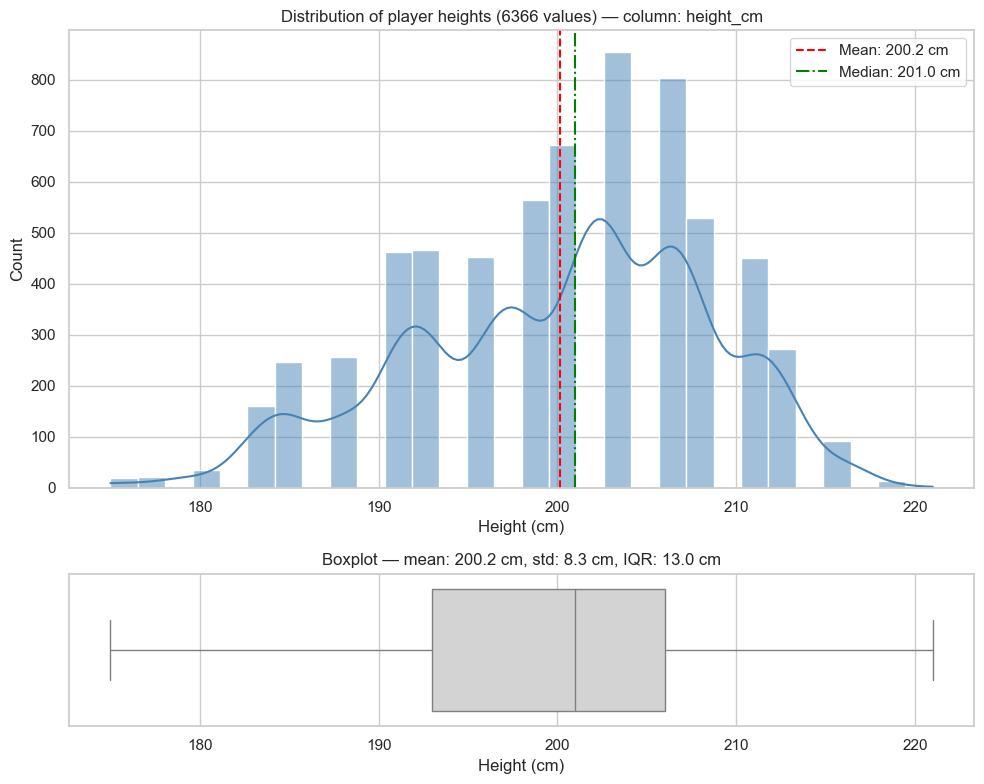

Count: 6366, Mean: 200.2 cm, Median: 201.0 cm, Std: 8.3 cm, IQR: 13.0 cm


In [12]:
import re
import numpy as np
import seaborn as sns

# descriptive plot of player heights
import matplotlib.pyplot as plt

# choose dataframe to use (prefer NBA-filtered if available)
df_source = None
if 'merged_NBA' in globals():
    df_source = merged_NBA
elif 'merged' in globals():
    df_source = merged
else:
    raise RuntimeError("No dataframe named 'merged' or 'merged_NBA' found in the notebook.")

# find a height column by common names
height_col = None
candidates = ['height','height_cm','height_cm_stats','height_stats','height_m','height_in','height_inches','player_height','ht']
for c in df_source.columns:
    lc = c.lower().replace(' ', '_')
    if any(k in lc for k in candidates) or lc in candidates:
        height_col = c
        break

if height_col is None:
    # try more generic search for columns containing 'height' or 'ht'
    for c in df_source.columns:
        if 'height' in c.lower() or (c.lower() == 'ht'):
            height_col = c
            break

if height_col is None:
    print("No height column detected. Available columns:", list(df_source.columns))
else:
    # robust parser to convert many height formats to centimeters
    def to_cm(x):
        if pd.isna(x):
            return np.nan
        s = str(x).strip().lower()
        if s == '':
            return np.nan
        # numeric only
        if re.fullmatch(r'\d+(\.\d+)?', s):
            val = float(s)
            if val > 100:  # likely already cm
                return val
            if val <= 8:   # likely meters
                return val * 100
            # otherwise assume inches
            return val * 2.54
        # contains 'cm'
        if 'cm' in s:
            m = re.search(r'(\d+(\.\d+)?)', s)
            if m:
                return float(m.group(1))
        # feet/inches patterns like 6-7, 6'7", 6 ft 7 in
        # try split on feet markers
        if "'" in s or "ft" in s or '-' in s:
            # split feet and inches
            parts = re.split(r"[\'\-\s]ft|ft|'|-|\"", s)
            # fallback numeric extraction
            nums = re.findall(r'\d+(\.\d+)?', s)
            if parts and parts[0].strip().isdigit():
                feet = float(parts[0].strip())
                inch = 0.0
                if len(parts) > 1 and parts[1].strip() and re.match(r'^\d+(\.\d+)?$', parts[1].strip()):
                    inch = float(parts[1].strip())
                return (feet * 12 + inch) * 2.54
            if nums:
                # treat first number as feet if small (<=8) else inches
                v = float(nums[0])
                if v <= 8:
                    return (v * 12 + (float(nums[1]) if len(nums) > 1 else 0)) * 2.54
                return v * 2.54
        # contains inches unit
        if 'in' in s or 'inch' in s:
            m = re.search(r'(\d+(\.\d+)?)', s)
            if m:
                return float(m.group(1)) * 2.54
        # fallback: extract any number and guess
        nums = re.findall(r'\d+(\.\d+)?', s)
        if nums:
            val = float(nums[0])
            if val > 100:
                return val
            if val <= 8:
                return val * 100
            return val * 2.54
        return np.nan

    # convert column to cm
    heights_cm = df_source[height_col].map(to_cm).astype(float)

    # descriptive stats
    count = heights_cm.notna().sum()
    mean = heights_cm.mean()
    median = heights_cm.median()
    std = heights_cm.std()
    q1 = heights_cm.quantile(0.25)
    q3 = heights_cm.quantile(0.75)

    # plotting
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios':[3, 1]})
    # histogram + KDE
    sns.histplot(heights_cm.dropna(), kde=True, bins=30, color='steelblue', ax=axes[0])
    axes[0].axvline(mean, color='red', linestyle='--', label=f"Mean: {mean:.1f} cm")
    axes[0].axvline(median, color='green', linestyle='-.', label=f"Median: {median:.1f} cm")
    axes[0].set_title(f"Distribution of player heights ({count} values) — column: {height_col}")
    axes[0].set_xlabel("Height (cm)")
    axes[0].legend()

    # boxplot
    sns.boxplot(x=heights_cm.dropna(), color='lightgray', ax=axes[1])
    axes[1].set_xlabel("Height (cm)")
    axes[1].set_title(f"Boxplot — mean: {mean:.1f} cm, std: {std:.1f} cm, IQR: {q3 - q1:.1f} cm")

    plt.tight_layout()
    plt.show()

    # print summary
    print(f"Count: {count}, Mean: {mean:.1f} cm, Median: {median:.1f} cm, Std: {std:.1f} cm, IQR: {(q3 - q1):.1f} cm")

In [13]:
# garder uniquement les lignes où la league est NBA
merged_NBA = merged[merged['League'] == 'NBA']

# ou si la colonne est en minuscules
# merged = merged[merged['league'] == 'NBA']

print(f"Lignes restantes après filtrage : {len(merged)}")

# sauvegarder le dataset filtré

merged_NBA.head()

Lignes restantes après filtrage : 6366


,League,Season,Stage,Player,Team,GP,MIN,FGM,FGA,3PM,...,position,height_anthro,height_with_shoes,weight_anthro,wingspan,standing_reach,body_fat_percentage,hand_length,hand_width,draft_year
0,NBA,1999 - 2000,Regular_Season,Glen Rice,LAL,80,2530.0,421,980,84,...,SF/SG,194.31,197.48,95.62,206.38,257.81,8.45,21.59,22.86,2013
1,NBA,1999 - 2000,Regular_Season,Jaren Jackson,SAS,81,1691.0,186,488,108,...,PF/C,207.64,211.46,107.05,226.70,279.40,7.20,25.40,25.40,2018
2,NBA,1999 - 2000,Playoffs,Glen Rice,LAL,23,766.0,93,228,28,...,SF/SG,194.31,197.48,95.62,206.38,257.81,8.45,21.59,22.86,2013
7,NBA,2000 - 2001,Regular_Season,Glen Rice,NYK,75,2212.0,331,752,82,...,SF/SG,194.31,197.48,95.62,206.38,257.81,8.45,21.59,22.86,2013
8,NBA,2000 - 2001,Regular_Season,Eric Williams,BOS,81,1744.0,162,448,46,...,C/PF,201.30,205.10,129.27,224.16,270.51,13.00,NaN,NaN,2006
